# Introduction to Decision Trees
In this notebook we will

1. introduce decision trees,
2. Define Gini Impurity and
3. Review the CART algorithm used to fit a decision tree.


## What is a Decision Tree?


A **Decision Tree** is a machine learning model that makes predictions by repeatedly splitting data into subsets based on certain conditions.

- **How it works:**
  - It asks a series of questions to classify data or make predictions.
  - Each question splits the data into smaller groups (nodes) based on features and conditions.


__Key Terms__

- **Nodes** contain:
  - `feature`: The feature used for splitting (e.g., Age, Position).
  - `threshold`: The condition used to split the data.
  - **`gini`**: The Gini impurity at the node. Lower values mean purer groups.
  - **`samples`**: The number of data points at the node.
  - **`value`**: The number of data points belonging to each class at the node.
  - **`class`**: The predicted class at that node.
- **Edges** show the conditions leading to child nodes.
- **Leaf Nodes** contain the final prediction.


- **Depth:** The number of levels in the tree.


__Example__  Classifying Fruits

We will classify fruits into two categories: **Apple** and **Grape** using:
1. **Size**: Small or Large.
2. **Color**: Red or Green.


|--- Large <= 0.50
|   |--- class: Grape
|--- Large >  0.50
|   |--- class: Apple



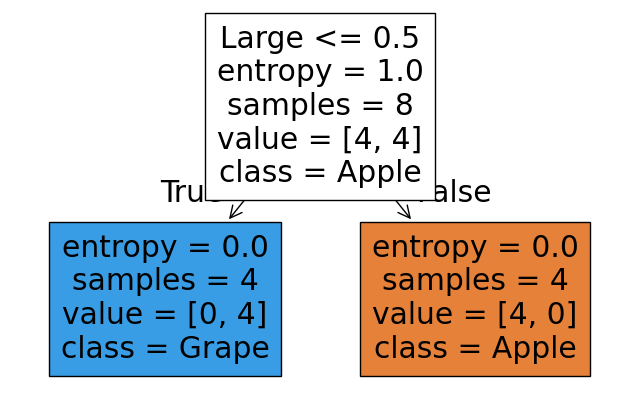

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

# A tiny fruit dataset: two yes/no features and a label
df = pd.DataFrame({
    "Large": [1, 1, 0, 0, 1, 0, 1, 0],   # 1 = large, 0 = small
    "Red":   [1, 0, 1, 0, 1, 1, 0, 0],   # 1 = red,   0 = green
    "Fruit": ["Apple", "Apple", "Grape", "Grape", "Apple", "Grape", "Apple", "Grape"],
})

X = df[["Large", "Red"]]
y = df["Fruit"]

# Build the tree using entropy to choose splits
tree = DecisionTreeClassifier(criterion="entropy", random_state=0)
tree.fit(X, y)

# Show the tree as text and as a picture
print(export_text(tree, feature_names=list(X.columns)))

plt.figure(figsize=(8, 5))
plot_tree(tree, feature_names=X.columns, class_names=tree.classes_, filled=True)
plt.show()

How to read this plot??

Let's start with the root (top box). This is where we have all 8 fruits before any question is asked.


`Large <= 0.5:` is the question the tree asks. Since Large is 0 or 1, this really means "Is it small?"


`entropy = 1.0:` the group is a 50/50 mix, so it's as messy as two classes can get.


`samples = 8:` every fruit starts here.


`value = [4, 4]:` 4 apples and 4 grapes, in the order of class_names (Apple first, then Grape).


`class = Apple:` what the tree would predict if it stopped here. It's a tie, so scikit-learn picks the first class. Don't read anything into it.

Take a moment and try to read other boxes.


## **Decision Tree on Iris Dataset**


In [11]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Iris Dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a Decision Tree
dt = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=42)
dt.fit(X_train, y_train)



DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

In [12]:
# Predict and Evaluate
y_pred = dt.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")


Accuracy: 0.98


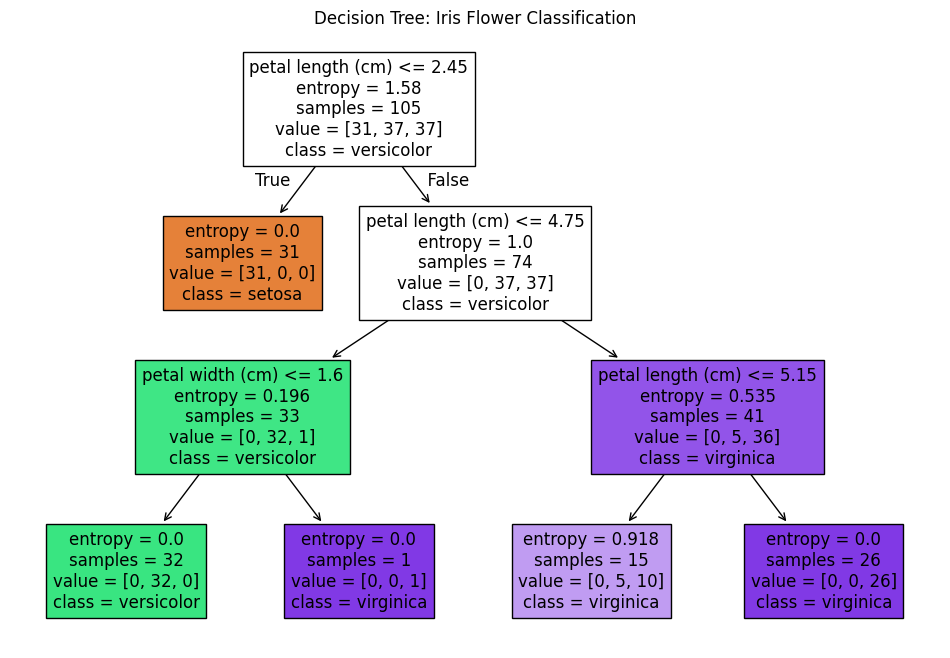

In [13]:

# Visualize the Tree
plt.figure(figsize=(12, 8))
plot_tree(dt, feature_names=feature_names, class_names=class_names, filled=True)
plt.title("Decision Tree: Iris Flower Classification")
plt.show()

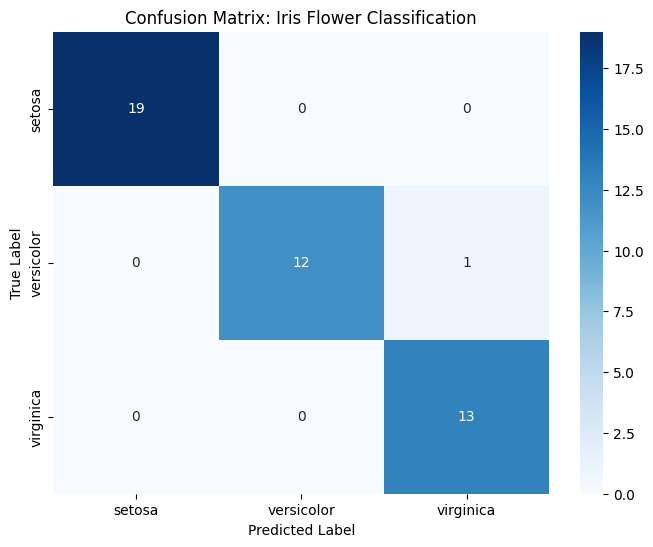

In [14]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
# Plot Confusion Matrix using Seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix: Iris Flower Classification")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## 1. Your Turn: **Apply a decision tree to MNIST**

1. Load MNIST with `fetch_openml("mnist_784", as_frame=False)`. Each image is 784 pixel values, and the label is the digit 0–9.
2. Split the data into training and test sets with `train_test_split`, keeping 20% for testing.
3. Train a `DecisionTreeClassifier` with `criterion="entropy"`.
4. Report the accuracy on both the training set and the test set.
5. Try `max_depth` values of 5, 10, 20, and None, and record both accuracies for each.
6. In two sentences, explain which depth works best and what the gap between training and test accuracy tells you.

The full MNIST dataset has 70,000 images, so training takes a minute or so. If that's too slow for you, switch to`load_digits()`, which has 1,800 small 8×8 images and runs instantly.




In [21]:
#datasets
from sklearn.datasets import fetch_openml
from sklearn.datasets import load_digits
#DT and plot tree
from sklearn.tree import DecisionTreeClassifier, plot_tree

#train test split
from sklearn.model_selection import train_test_split

#metrics
from sklearn.metrics import accuracy_score, confusion_matrix

#for plotting
import matplotlib.pyplot as plt
import seaborn as sns


In [18]:
#Load MNIST with fetch_openml("mnist_784", as_frame=False).
digits = fetch_openml("mnist_784", as_frame=False)
X = digits.data
y = digits.target
feature_names = digits.feature_names
class_names = digits.target_names

In [ ]:
# if the full dataset is too large, load the MNIST-like Digits Dataset (from sklearn)
digits = load_digits()
X = digits.data  # Features: 8x8 pixel images, flattened to 1D arrays
y = digits.target  # Target: Labels (digits 0-9)
feature_names = [f'Pixel {i}' for i in range(X.shape[1])]
class_names = [str(i) for i in range(10)]  # Digits 0 to 9


In [ ]:
# Split Data

In [ ]:
# Train a Decision Tree

In [ ]:
# Visualize the Decision Tree


In [ ]:
# Find predictions and print accuracy

In [ ]:
# Confusion Matrix

##2.
 Now switch to criterion="gini" and train again with your best settings. How do the accuracy and the tree depth compare with entropy? Look up Gini impurity to see what it measures and how it differs from entropy.




##3.
 Which settings gave the best test accuracy? What does the gap between training and test accuracy tell you about the model?